<a href="https://colab.research.google.com/github/HARISHPG21/tredence-ai-intern-casestudy/blob/main/tredence_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-Pruning Neural Network - Tredence Case Study

**Instructions:**
1. Go to Runtime > Change runtime type > select T4 GPU > Save
2. Run each cell in order (Shift + Enter)
3. After the last cell, download the 3 PNG plots and upload to GitHub

## Step 1 - Check GPU

In [1]:
import torch
print('PyTorch version :', torch.__version__)
print('GPU available   :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name        :', torch.cuda.get_device_name(0))
else:
    print('No GPU - go to Runtime > Change runtime type > T4 GPU')

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4


## Step 2 - Install dependencies

In [2]:
!pip install tqdm --quiet
print('Done!')

Done!


## Step 3 - Upload your script

Run the cell below, click Choose Files, and upload self_pruning_nn.py from your Downloads folder.

In [ ]:
from google.colab import files
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))

## Step 4 - Run the full experiment

Trains 3 models (one per lambda value) and generates all plots. Takes 5-10 minutes on GPU.

In [4]:
!mkdir -p results
!python self_pruning_nn.py --epochs 20 --outdir results

Device : cuda
GPU    : Tesla T4
100% 170M/170M [00:13<00:00, 12.4MB/s]
CIFAR-10 loaded  |  train=50,000  test=10,000

────────────────────────────────────────────────────────────
  lambda = 1e-05   |   epochs = 20   |   device = cuda
────────────────────────────────────────────────────────────
  Epoch   1/20  |  loss=9.9755  |  acc=40.72%  |  sparsity=0.0%  |  time=34s
  Epoch   5/20  |  loss=6.0147  |  acc=48.75%  |  sparsity=0.0%  |  time=173s
  Epoch  10/20  |  loss=4.3926  |  acc=52.61%  |  sparsity=0.0%  |  time=345s
  Epoch  15/20  |  loss=3.8920  |  acc=54.06%  |  sparsity=0.0%  |  time=519s
  Epoch  20/20  |  loss=3.7814  |  acc=54.32%  |  sparsity=0.0%  |  time=692s

  Layer-wise sparsity (lambda=1e-05):
    fc1       active=1,572,864 / 1,572,864  (0.0% pruned)
    fc2       active=131,072 / 131,072  (0.0% pruned)
    fc3       active=32,768 / 32,768  (0.0% pruned)
    fc4       active= 1,280 /  1,280  (0.0% pruned)
    TOTAL     active=1,737,984 / 1,737,984  (0.0% pruned)

──

## Step 5 - Preview the plots

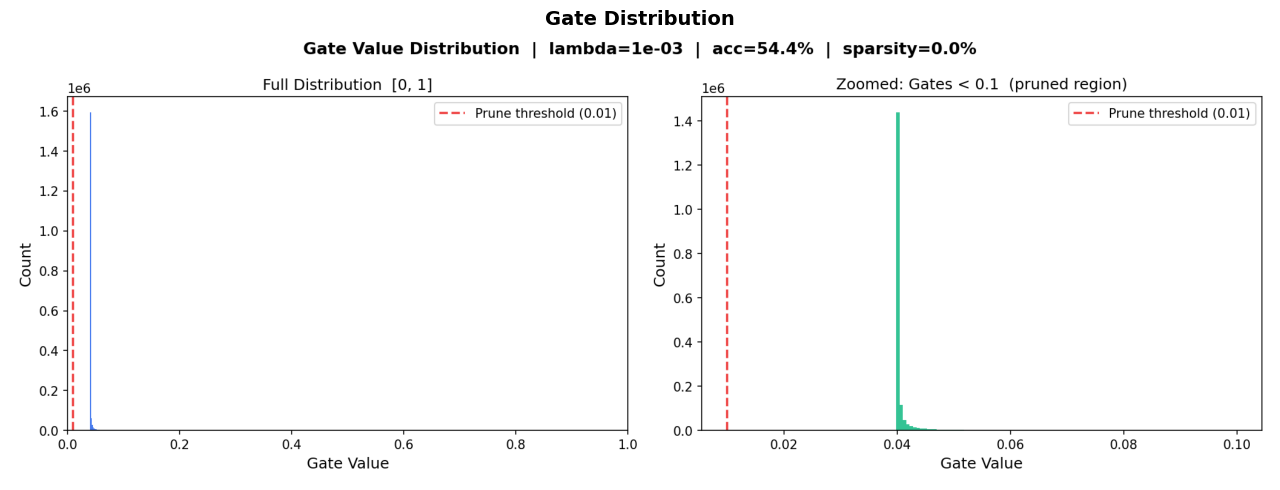

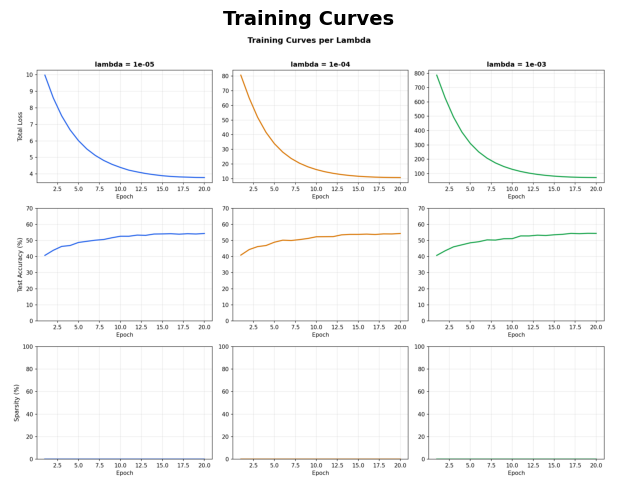

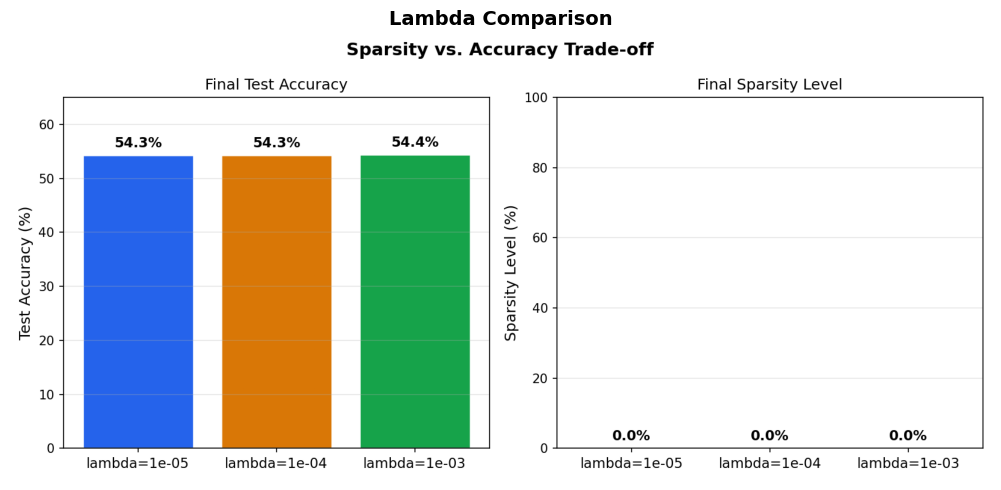

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

plots = [
    ('results/gate_distribution.png', 'Gate Distribution'),
    ('results/training_curves.png',   'Training Curves'),
    ('results/lambda_comparison.png', 'Lambda Comparison'),
]

for path, title in plots:
    if os.path.exists(path):
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(mpimg.imread(path))
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('Plot not found:', path)

## Step 6 - Download the plots

Downloads all 3 PNG files to your computer. Then upload them to your GitHub repo.

In [6]:
from google.colab import files
import os

for plot in ['gate_distribution.png', 'training_curves.png', 'lambda_comparison.png']:
    path = 'results/' + plot
    if os.path.exists(path):
        files.download(path)
        print('Downloaded:', plot)
    else:
        print('Not found:', path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: gate_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: lambda_comparison.png
